# Sheet 03 - Convolutional Neural Networks

Introduction to Deep Learning - Summer Semester 2026

Ulf Krumnack & Robin Rawiel - Universität OsnabrückDue: May 3, 2026

## Task 1: Theory Questions \[8 points\]

These questions revisit the core ideas from Lecture 04 and the CNN
script: images as tensors, convolution as local pattern detection, and
the architectural choices that make CNNs effective for vision.

### 1.1 Convolution Operation \[2 points\]

1.  Given a $5 \times 5$ input image and a $3 \times 3$ kernel, compute
    the output size for:
    - No padding, stride 1
    - Padding 1, stride 1
    - No padding, stride 2

    State the general formula for the output size given input size $W$,
    kernel size $K$, padding $P$, and stride $S$.

<h4 style="color: green">Answer</h4>

The general formula for the spatial output size is:

$$\text{out} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$

where $W$ = input size, $K$ = kernel size, $P$ = padding, $S$ = stride.

For a $5 \times 5$ input and a $3 \times 3$ kernel ($W=5,\,K=3$):

| Configuration | Calculation | Output size |
|---|---|---|
| No padding, stride 1 | $\lfloor(5-3+0)/1\rfloor+1$ | $3 \times 3$ |
| Padding 1, stride 1 | $\lfloor(5-3+2)/1\rfloor+1$ | $5 \times 5$ |
| No padding, stride 2 | $\lfloor(5-3+0)/2\rfloor+1$ | $2 \times 2$ |

<!-- -->

1.  Perform **by hand** the 2D convolution (cross-correlation) of the
    following input with the given kernel (stride 1, no padding):

    Input:

        1 0 1 0
        0 1 0 1
        1 0 1 0
        0 1 0 1

    Kernel:

        1  0 -1
        1  0 -1
        1  0 -1

<h4 style="color: green">Answer</h4>

![2D convolution by hand](2D%20convolution%20by%20hand.png)

### 1.2 Architectural Concepts \[3 points\]

1.  What is the **receptive field** of a neuron in a CNN? How does it
    grow with depth?

<h4 style="color: green">Answer</h4>

The **receptive field** of a neuron is the region of the original input image that can influence its output value. In early layers, each unit only sees a small local patch (e.g. 3×3), so its receptive field is small. As we go deeper, each successive layer's units depend on the outputs of the previous layer, which themselves already aggregate information from a local neighborhood. Therefore the receptive field grows with depth — later neurons can indirectly depend on much larger parts of the input and encode more global structure.

<!-- -->

1.  Explain the purpose of **max pooling**. What are its advantages and
    disadvantages?

<h4 style="color: green">Answer</h4>

**Purpose:** Max pooling spatially downsamples a feature map by keeping only the largest value in each local patch (e.g. 2×2). It reduces spatial resolution while retaining the strongest activations — the presence of a detected feature — regardless of its exact position within the patch.

**Advantages:**
- Reduces spatial dimensions → lower memory and compute cost in subsequent layers.
- Introduces local translation invariance: small shifts in the input do not change the output.
- Discards weak, noise-like activations and keeps only dominant features.

**Disadvantages:**
- Throws away precise spatial location information (exact position of features is lost).
- Has no learnable parameters — cannot be adapted to the task.
- Irreversible: the discarded values cannot be recovered in later layers.

<!-- -->

1.  What problem do **residual connections** (skip connections) solve in
    deep networks? Write down the residual mapping.

<h4 style="color: green">Answer</h4>

**Problem solved:** Very deep plain networks suffer from the **vanishing gradient** problem. During backpropagation, gradients are multiplied through many layers; if each factor is less than 1, the gradient shrinks exponentially toward the earlier layers, which then receive almost no update signal and learn very slowly. As a result, a deeper plain network can actually train *worse* than a shallower one.

**Residual mapping:** Instead of asking a block to learn the full mapping $H(\mathbf{x})$ directly, we let it learn only the residual:
$$F(\mathbf{x}) = H(\mathbf{x}) - \mathbf{x}$$
and add a shortcut connection that passes the input through unchanged:
$$\mathbf{y} = F(\mathbf{x}) + \mathbf{x}$$
This gives gradients a direct path backward and makes it easy for the block to learn the identity function (simply set $F \approx 0$), which stabilizes training in very deep networks.

### 1.3 Images, Channels, and Parameter Efficiency \[3 points\]

1.  Suppose we work with RGB images of size $32 \times 32$. What is the
    tensor shape of
    - a single image, and
    - a mini-batch of 64 such images

    in channel-first notation?

<h4 style="color: green">Answer</h4>

Using the channel-first convention $\mathbf{X} \in \mathbb{R}^{C \times H \times W}$ (as in PyTorch):

- Single image: $\mathbf{X} \in \mathbb{R}^{3 \times 32 \times 32}$
- Mini-batch of 64: $\mathbf{X} \in \mathbb{R}^{64 \times 3 \times 32 \times 32}$

<!-- -->

1.  Consider a convolutional layer with input shape
    $3 \times 32 \times 32$, 16 output channels, kernel size
    $3 \times 3$, stride 1, and no padding.

    - How many trainable parameters does this layer have if each output
      channel also has one bias?
    - What is the output activation shape?

<h4 style="color: green">Answer</h4>

From the lecture, the number of trainable parameters for a convolutional layer is:
$$k_h \cdot k_w \cdot C_{\text{in}} \cdot C_{\text{out}} + C_{\text{out}}$$

Here $k_h = k_w = 3$, $C_{\text{in}} = 3$, $C_{\text{out}} = 16$:
$$3 \cdot 3 \cdot 3 \cdot 16 + 16 = 432 + 16 = \mathbf{448 \text{ parameters}}$$

Output spatial size (no padding, stride 1): $\lfloor(32 - 3 + 0)/1\rfloor + 1 = 30$

Output shape: $\mathbf{16 \times 30 \times 30}$

<!-- -->

1.  Suppose we flatten the same input image into a vector of length
    $3 \cdot 32 \cdot 32 = 3072$ and feed it into a fully connected
    layer with 16 output units.

    - How many trainable parameters does this fully connected layer
      have?
    - Briefly explain why the convolutional layer above is much more
      parameter-efficient.

<h4 style="color: green">Answer</h4>

A fully connected layer with 3072 inputs and 16 outputs has:
$$3072 \cdot 16 + 16 = \mathbf{49{,}168 \text{ parameters}}$$

The convolutional layer needs only **448** vs **49,168** for the FC layer — a factor of ~110× fewer.

The reason is **weight sharing**: a convolutional filter has fixed size $C_{\text{in}} \times k_h \times k_w$ and is reused at every spatial position. The same local pattern detector is applied across the whole image. A fully connected layer, by contrast, has an independent weight for every input-output pair, so it scales with the full spatial resolution. CNN's local connectivity and weight sharing are exactly what make it so parameter-efficient.

## Task 2: CNN on CIFAR-10 \[12 points\]

**Learning objectives:**

- Build a CNN architecture in PyTorch
- Train, evaluate, and visualize CNN performance
- Visualize learned filters and confusion matrix

You have already seen the main PyTorch building blocks in Practice 03.
In this sheet, the goal is to combine them into one complete CNN
pipeline for CIFAR-10.

### 2.1 Load and Explore CIFAR-10 \[1 point\]

As in the practice notebook, keep the model and tensors on the same
`device`. The call `permute(1, 2, 0)` is only for visualization, because
`matplotlib` expects channel-last images while PyTorch stores image
tensors channel-first.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CLASSES = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

Using device: cpu


Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train examples: 50000
test examples : 10000
image batch shape: (64, 3, 32, 32)
label batch shape: (64,)


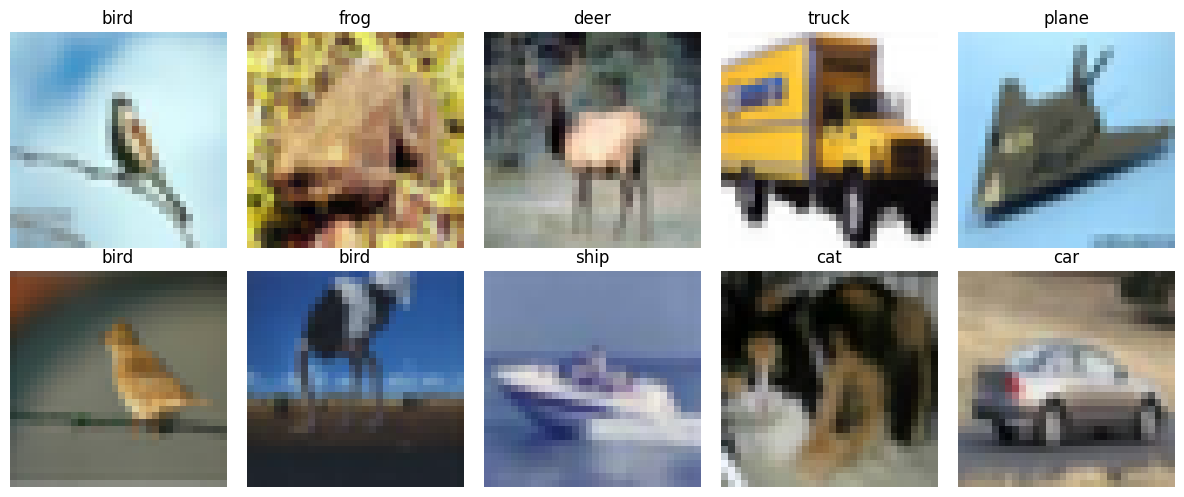

In [12]:
# ref: practice03
from datasets import load_dataset
from torch.utils.data import Dataset

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Toronto server returns 503; load identical data from HuggingFace mirror instead
class HFCifar10(Dataset):
    def __init__(self, split, transform=None):
        self.data, self.transform = split, transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img, label = self.data[idx]["img"], self.data[idx]["label"]
        return self.transform(img) if self.transform else img, label

hf = load_dataset("uoft-cs/cifar10")  # cached in ~/.cache/huggingface/datasets
train_dataset = HFCifar10(hf["train"], transform=transform)
test_dataset  = HFCifar10(hf["test"],  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

print(f"train examples: {len(train_dataset)}")
print(f"test examples : {len(test_dataset)}")

# ref: practice03 — unnormalize + visualize one mini-batch
def unnormalize(images):
    mean = torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1)
    std  = torch.tensor(CIFAR_STD).view(1, 3, 1, 1)
    return torch.clamp(images * std + mean, 0.0, 1.0)

images, labels = next(iter(train_loader))
print("image batch shape:", tuple(images.shape))
print("label batch shape:", tuple(labels.shape))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image, label in zip(axes.flat, unnormalize(images[:10]), labels[:10]):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(CLASSES[int(label)])
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Build the CNN \[3 points\]

Design a CNN with the following architecture:

| Layer | Details |
|----|----|
| Conv2d | 3 → 32, kernel 3, padding 1 |
| BatchNorm2d + ReLU |  |
| Conv2d | 32 → 32, kernel 3, padding 1 |
| BatchNorm2d + ReLU + MaxPool2d(2) |  |
| Conv2d | 32 → 64, kernel 3, padding 1 |
| BatchNorm2d + ReLU |  |
| Conv2d | 64 → 64, kernel 3, padding 1 |
| BatchNorm2d + ReLU + MaxPool2d(2) |  |
| Flatten + Linear(64×8×8 → 256) + ReLU + Dropout(0.5) |  |
| Linear(256 → 10) |  |

Hint: CIFAR-10 images start at spatial size $32 \times 32$. The two
`MaxPool2d(2)` layers reduce this to $16 \times 16$ and then
$8 \times 8$, which is why the first linear layer receives
$64 \times 8 \times 8$ input features.

In [13]:
# ref: practice03 — SmallCNN architecture; adapted to exercise spec (Dropout 0.5)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32×32 → 32×32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32×32 → 16×16
            # Block 2: 16×16 → 8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 16×16 → 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),             # 64×8×8 = 4096
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SimpleCNN().to(device)

# Sanity check: verify output shape and parameter count
with torch.no_grad():
    example_logits = model(images[:8].to(device))

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("output shape    :", tuple(example_logits.shape))  # expect (8, 10)
print("total parameters:", num_params)

output shape    : (8, 10)
total parameters: 1117354


### 2.3 Training Loop \[3 points\]

Remember that `model.train()` activates training-specific behavior such
as dropout, while `model.eval()` switches to evaluation mode. During
evaluation, `torch.no_grad()` disables gradient tracking and makes
inference cheaper.

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    # TODO: Your solution here


def evaluate(model, loader, criterion, device):
    """Evaluate the model. Returns (avg_loss, accuracy)."""
    # TODO: Your solution here

In [ ]:
# TODO: Your solution here

### 2.4 Visualize Learned Filters \[2 points\]

Extract and visualize the filters from the first convolutional layer.
After plotting them, briefly comment on whether some filters resemble
edge detectors, color-contrast detectors, or other local pattern
detectors from the lecture.

In [ ]:
# TODO: Your solution here

### 2.5 Confusion Matrix \[3 points\]

In [ ]:
# TODO: Your solution here

## Task 3: Adversarial Examples (Bonus) \[4 points\]

**Learning objectives:**

- Implement the Fast Gradient Sign Method (FGSM)
- Understand adversarial vulnerability of neural networks
- Visualize adversarial perturbations

### 3.1 Load a Trained Model

Use the model trained in Task 2 (or load a pretrained one).

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse model from Task 2- make sure it is in eval mode
model.eval()

# Load test data without augmentation
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

CLASSES = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

### 3.2 Implement FGSM \[2 points\]

The FGSM attack computes:
$$x_{\text{adv}} = x + \epsilon \cdot \text{sign}(\nabla_x \mathcal{L}(\theta, x, y))$$

In [ ]:
def fgsm_attack(model, images, labels, epsilon, criterion):
    """Generate adversarial examples using FGSM.

    Args:
        model: Trained model.
        images: Batch of input images (requires_grad will be set).
        labels: True labels.
        epsilon: Perturbation magnitude.
        criterion: Loss function.

    Returns:
        adversarial_images: Perturbed images clamped to valid range.
    """
    # TODO: Your solution here

### 3.3 Evaluate Robustness \[1 point\]

Test the model’s accuracy under FGSM attacks with
$\epsilon \in \{0, 0.01, 0.05, 0.1, 0.2, 0.3\}$.

In [ ]:
# TODO: Your solution here

### 3.4 Visualize Adversarial Examples

Show original and adversarial images side by side with their
predictions.

In [ ]:
# TODO: Your solution here

### 3.5 Reflection \[1 point\]

1.  Are the perturbations visible to the human eye at $\epsilon = 0.1$?
2.  Why does FGSM work - what property of neural networks does it
    exploit?
3.  Propose one defense mechanism against adversarial examples.